# Bike detector comparison inside STUDD

This notebook compares different drift detectors inside the STUDD mechanism on the Bike dataset.

We run a strongly supervised detector (SS) and use its first alarm as the reference drift indication.

For each detector, we record:

- all alarms produced by the detector
- all SS alarms
- teacher accuracy around the first SS alarm
- teacher-student disagreement around the first SS alarm
- teacher accuracy around the closest STUDD alarm
- teacher-student disagreement around the closest STUDD alarm

For Bike, the STUDD paper describes a difficult scenario where the teacher may perform poorly while the student can still mimic the teacher well. Therefore, we investigate both teacher accuracy and teacher-student disagreement.

In [16]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from capymoa.stream import NumpyStream

from capymoa.drift.detectors import (
    STUDD,
    ADWIN,
    PageHinkley,
    HDDMAverage,
    HDDMWeighted,
    CUSUM,
)

from helpers import (
    configure_matplotlib,
    rolling_mean,
)

from studd_utils import (
    make_teacher,
    make_student,
)

configure_matplotlib()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Bike data

The Bike task is a binary classification problem. According to the STUDD paper, the target is whether the rental bike count is high or low.

In [17]:
DATA_FILE = Path("data/Bike.data")

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. "
        "Make sure Bike.data is inside the notebooks/data/ folder."
    )

df = pd.read_csv(
    DATA_FILE,
    sep=None,
    engine="python",
    header=None,
)

print("Raw shape:", df.shape)

Raw shape: (17379, 5)


## Prepare features and target

The last column is used as the target label.

All previous columns are used as input features.

Feature columns are converted to numeric values.

Rows that cannot be converted to numeric feature values are removed. This also removes a possible header row if the file contains one.

The target labels are encoded with `LabelEncoder`.

In [18]:
label_col = df.columns[-1]

df = df.copy()
df = df.dropna().reset_index(drop=True)

X_df = df.drop(columns=[label_col]).copy()
y_raw = df[label_col].copy()

for col in X_df.columns:
    X_df[col] = pd.to_numeric(
        X_df[col],
        errors="coerce",
    )

valid_rows = X_df.notna().all(axis=1)

X_df = X_df.loc[valid_rows].reset_index(drop=True)
y_raw = y_raw.loc[valid_rows].reset_index(drop=True)

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    y_raw.astype(str)
)

X = X_df.to_numpy(dtype=float)

print("Prepared X shape:", X.shape)
print("Prepared y shape:", y.shape)
print("Number of classes:", len(label_encoder.classes_))

print("\nEncoded classes:")
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"{idx} -> {class_name}")

if len(label_encoder.classes_) != 2:
    print(
        "\nWARNING: Bike should have 2 classes according to the paper. "
        "Check whether the selected label column is correct."
    )

Prepared X shape: (17379, 4)
Prepared y shape: (17379,)
Number of classes: 2

Encoded classes:
0 -> high
1 -> low


## Experimental parameters

The teacher is trained on the first `W` labeled samples.

During monitoring, the teacher remains fixed and the student learns online to mimic the teacher.

The supervised signal detector monitors the teacher prediction error and provides a reference alarm.

For Bike, we use the paper's model choices:

- teacher: gradient boosting / XGB-like model
- student: random forest

The rolling curves use a window of 200 observations.

In [19]:
SEED = 1

N_STREAM = len(X)
W = 2000

N_TREES = 100
PH_DELTA = 0.001

TEACHER_TYPE = "sgbt"
STUDENT_TYPE = "rf"

LOCAL_WINDOW = 100
ROLLING_WINDOW = 200

if N_STREAM <= W:
    raise ValueError(
        f"N_STREAM={N_STREAM} must be larger than W={W}."
    )

print("N_STREAM:", N_STREAM)
print("W:", W)
print("Teacher:", TEACHER_TYPE)
print("Student:", STUDENT_TYPE)

N_STREAM: 17379
W: 2000
Teacher: sgbt
Student: rf


## Detectors

We compare the same five detectors used in the other notebooks.

In [20]:
DETECTORS = {
    "ADWIN": lambda: ADWIN(),
    "PageHinkley": lambda: PageHinkley(delta=PH_DELTA),
    "HDDMAverage": lambda: HDDMAverage(test_type="One-sided"),
    "HDDMWeighted": lambda: HDDMWeighted(test_type="One-sided"),
    "CUSUM": lambda: CUSUM(),
}

## Compute SS reference alarms

The supervised signal detector monitors the teacher error:

`teacher_error = 1 - teacher_correct`

All SS alarms are stored.

The first SS alarm is used as the reference drift indication for the Bike stream.

In [21]:
stream = NumpyStream(
    X,
    y,
    dataset_name="Bike",
)

schema = stream.get_schema()

ss_teacher = make_teacher(
    schema=schema,
    teacher_type=TEACHER_TYPE,
    seed=SEED,
    n_trees=N_TREES,
)

for _ in range(W):
    inst = stream.next_instance()
    ss_teacher.train(inst)

ss_detector = PageHinkley(delta=PH_DELTA)

ss_records = []
ss_drift_points = []

processed = W

while stream.has_more_instances() and processed < N_STREAM:

    inst = stream.next_instance()

    y_true = inst.y_index
    y_teacher = ss_teacher.predict(inst)

    if y_teacher is None:
        processed += 1
        continue

    teacher_correct = int(y_teacher == y_true)
    teacher_error = 1 - teacher_correct

    ss_detector.add_element(teacher_error)

    ss_detected_change = ss_detector.detected_change()

    if ss_detected_change:
        ss_drift_points.append(int(processed))

    ss_records.append({
        "t": int(processed),
        "teacher_correct": teacher_correct,
        "teacher_error": teacher_error,
        "ss_alarm": ss_detected_change,
    })

    processed += 1

ss_results = pd.DataFrame(ss_records)

if not ss_drift_points:
    raise RuntimeError(
        "No SS alarms detected. Cannot define reference drift point."
    )

reference_drift = int(ss_drift_points[0])

print("Total SS alarms:", len(ss_drift_points))
print("First 20 SS alarms:", ss_drift_points[:20])
print("Reference drift point:", reference_drift)

Total SS alarms: 5
First 20 SS alarms: [2709, 3598, 6433, 11221, 13842]
Reference drift point: 2709


In [22]:
ss_alarms_df = pd.DataFrame({
    "ss_alarm_index": range(1, len(ss_drift_points) + 1),
    "ss_alarm_time": ss_drift_points,
    "is_reference_drift_for_metrics": [
        i == 0 for i in range(len(ss_drift_points))
    ],
})

ss_alarms_df

,ss_alarm_index,ss_alarm_time,is_reference_drift_for_metrics
0,1,2709,True
1,2,3598,False
2,3,6433,False
3,4,11221,False
4,5,13842,False


## Data visualization

Before applying STUDD, we visualize the Bike stream to observe whether the input feature distribution changes over time.

We use:

- a PCA projection of the stream
- rolling means of all input features

In [23]:
N_VIS = min(N_STREAM, 20000)

X_vis = X[:N_VIS]

print("Visualization sample shape:", X_vis.shape)

Visualization sample shape: (17379, 4)


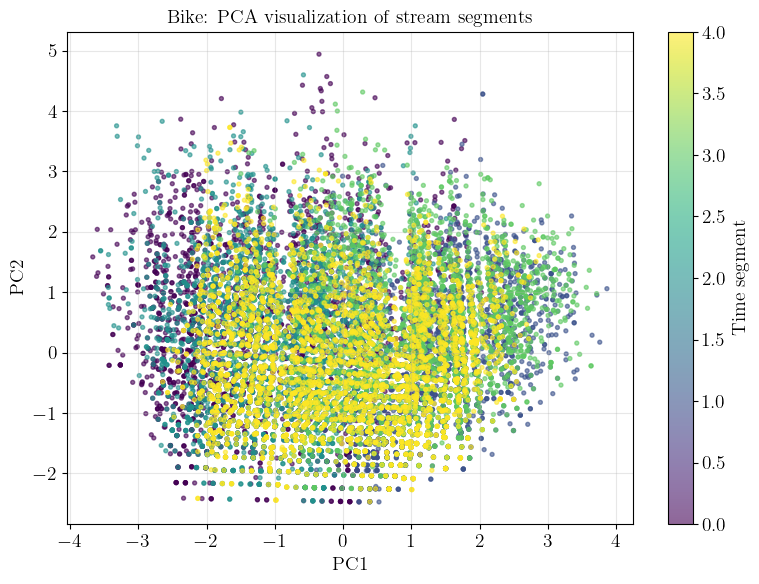

Explained variance ratio: [0.49912163 0.32257138]
Total explained variance: 0.8216930027459602


In [24]:
X_scaled = StandardScaler().fit_transform(X_vis)

pca = PCA(
    n_components=2,
    random_state=SEED,
)

X_pca = pca.fit_transform(X_scaled)

segment_size = max(1, len(X_vis) // 5)

segments = np.minimum(
    np.arange(len(X_vis)) // segment_size,
    4,
)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=segments,
    s=8,
    alpha=0.6,
)

plt.title("Bike: PCA visualization of stream segments")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Time segment")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

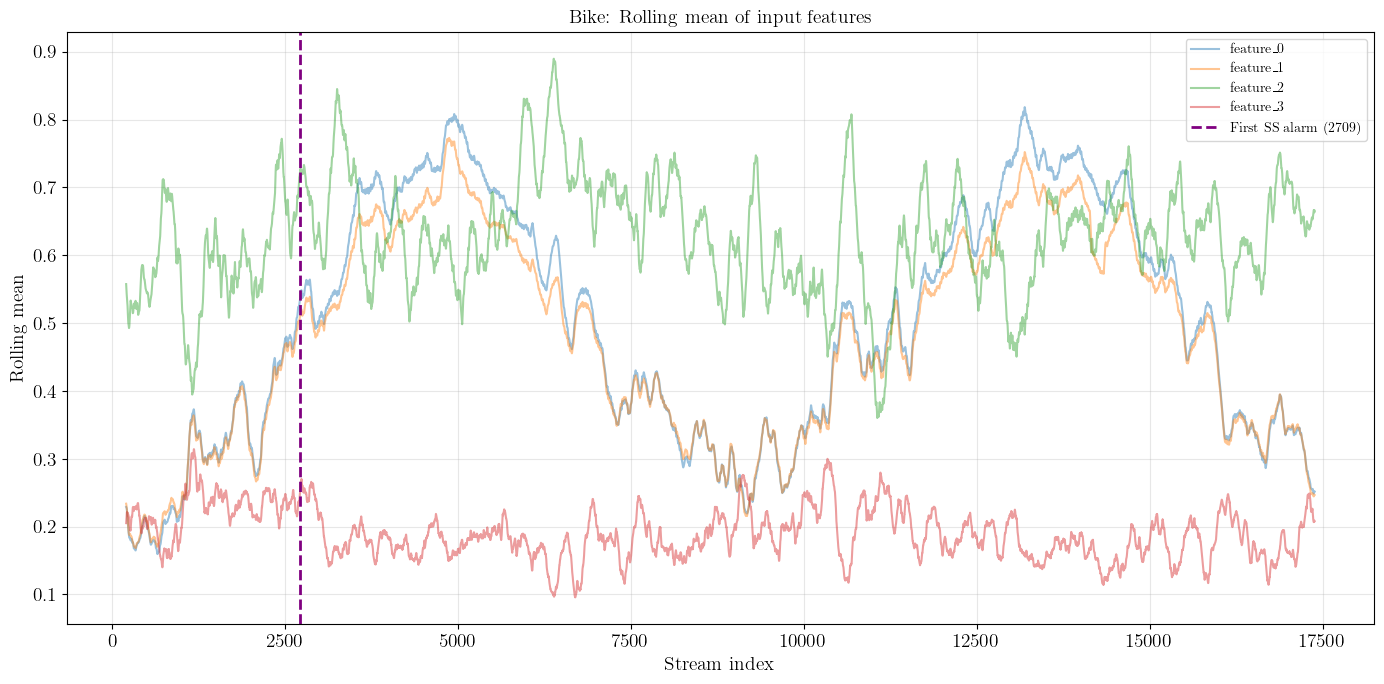

In [25]:
FEATURE_ROLLING_WINDOW = 200

X_plot_df = pd.DataFrame(
    X,
    columns=[f"feature_{i}" for i in range(X.shape[1])]
)

rolling_feature_means = (
    X_plot_df
    .rolling(FEATURE_ROLLING_WINDOW)
    .mean()
)

plt.figure(figsize=(14, 7))

for feature in rolling_feature_means.columns:
    plt.plot(
        rolling_feature_means.index,
        rolling_feature_means[feature],
        linewidth=1.5,
        alpha=0.45,
        label=feature,
    )

plt.axvline(
    reference_drift,
    color="purple",
    linestyle="--",
    linewidth=2,
    label=f"First SS alarm ({reference_drift})",
)

plt.title("Bike: Rolling mean of input features")
plt.xlabel("Stream index")
plt.ylabel("Rolling mean")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Run STUDD with each detector

Each STUDD detector is evaluated independently.

For each detector, we recreate the Bike stream, train the same teacher model, initialize the same student model and run STUDD.

The only changing component is the drift detector used inside STUDD.

For each detector, we store:

- teacher accuracy
- teacher-student agreement
- teacher-student disagreement
- STUDD alarms

In [26]:
comparison_runs = {}

for detector_name, detector_factory in DETECTORS.items():

    print(f"Running {detector_name}...")

    stream = NumpyStream(
        X,
        y,
        dataset_name="Bike",
    )

    schema = stream.get_schema()

    teacher = make_teacher(
        schema=schema,
        teacher_type=TEACHER_TYPE,
        seed=SEED,
        n_trees=N_TREES,
    )

    for _ in range(W):
        inst = stream.next_instance()
        teacher.train(inst)

    student = make_student(
        schema=schema,
        student_type=STUDENT_TYPE,
        seed=SEED,
        n_trees=N_TREES,
    )

    studd = STUDD(
        student=student,
        min_n_instances=W,
        detector=detector_factory(),
    )

    records = []
    studd_drift_points = []

    processed = W

    while stream.has_more_instances() and processed < N_STREAM:

        inst = stream.next_instance()

        y_true = inst.y_index
        y_teacher = teacher.predict(inst)

        if y_teacher is None:
            processed += 1
            continue

        y_student = student.predict(inst)

        if y_student is None:
            agreement = np.nan
            disagreement = np.nan
        else:
            agreement = int(y_student == y_teacher)
            disagreement = 1 - agreement

        teacher_correct = int(y_teacher == y_true)

        studd.add_element(
            inst,
            y_teacher,
        )

        detected_change = studd.detected_change()

        if detected_change:
            studd_drift_points.append(int(processed))

        records.append({
            "t": int(processed),
            "teacher_correct": teacher_correct,
            "agreement": agreement,
            "disagreement": disagreement,
            "drift_alarm": detected_change,
        })

        processed += 1

    results = pd.DataFrame(records)

    first_alarm = (
        studd_drift_points[0]
        if studd_drift_points
        else None
    )

    closest_alarm = (
        min(
            studd_drift_points,
            key=lambda alarm: abs(alarm - reference_drift),
        )
        if studd_drift_points
        else None
    )

    closest_alarm_delay = (
        closest_alarm - reference_drift
        if closest_alarm is not None
        else None
    )

    reference_before_accuracy = results[
        (results["t"] >= reference_drift - LOCAL_WINDOW)
        &
        (results["t"] < reference_drift)
    ]["teacher_correct"]

    reference_after_accuracy = results[
        (results["t"] >= reference_drift)
        &
        (results["t"] < reference_drift + LOCAL_WINDOW)
    ]["teacher_correct"]

    reference_before_disagreement = results[
        (results["t"] >= reference_drift - LOCAL_WINDOW)
        &
        (results["t"] < reference_drift)
    ]["disagreement"].dropna()

    reference_after_disagreement = results[
        (results["t"] >= reference_drift)
        &
        (results["t"] < reference_drift + LOCAL_WINDOW)
    ]["disagreement"].dropna()

    reference_accuracy_delta = (
        reference_after_accuracy.mean()
        - reference_before_accuracy.mean()
        if len(reference_before_accuracy) and len(reference_after_accuracy)
        else np.nan
    )

    reference_disagreement_delta = (
        reference_after_disagreement.mean()
        - reference_before_disagreement.mean()
        if len(reference_before_disagreement) and len(reference_after_disagreement)
        else np.nan
    )

    if closest_alarm is not None:

        closest_alarm_before_accuracy = results[
            (results["t"] >= closest_alarm - LOCAL_WINDOW)
            &
            (results["t"] < closest_alarm)
        ]["teacher_correct"]

        closest_alarm_after_accuracy = results[
            (results["t"] >= closest_alarm)
            &
            (results["t"] < closest_alarm + LOCAL_WINDOW)
        ]["teacher_correct"]

        closest_alarm_before_disagreement = results[
            (results["t"] >= closest_alarm - LOCAL_WINDOW)
            &
            (results["t"] < closest_alarm)
        ]["disagreement"].dropna()

        closest_alarm_after_disagreement = results[
            (results["t"] >= closest_alarm)
            &
            (results["t"] < closest_alarm + LOCAL_WINDOW)
        ]["disagreement"].dropna()

        closest_alarm_accuracy_delta = (
            closest_alarm_after_accuracy.mean()
            - closest_alarm_before_accuracy.mean()
            if len(closest_alarm_before_accuracy) and len(closest_alarm_after_accuracy)
            else np.nan
        )

        closest_alarm_disagreement_delta = (
            closest_alarm_after_disagreement.mean()
            - closest_alarm_before_disagreement.mean()
            if len(closest_alarm_before_disagreement) and len(closest_alarm_after_disagreement)
            else np.nan
        )

    else:

        closest_alarm_accuracy_delta = np.nan
        closest_alarm_disagreement_delta = np.nan

    summary = {
        "detector": detector_name,

        "num_alarms": len(studd_drift_points),
        "alarms": studd_drift_points,

        "first_alarm": first_alarm,

        "closest_alarm": closest_alarm,
        "closest_alarm_delay_from_ss": closest_alarm_delay,

        "reference_accuracy_delta": reference_accuracy_delta,
        "reference_disagreement_delta": reference_disagreement_delta,

        "closest_alarm_accuracy_delta": closest_alarm_accuracy_delta,
        "closest_alarm_disagreement_delta": closest_alarm_disagreement_delta,
    }

    comparison_runs[detector_name] = {
        "summary": summary,
        "results": results,
        "studd_drift_points": studd_drift_points,
    }

print("Done.")

Running ADWIN...


Running PageHinkley...
Running HDDMAverage...
Running HDDMWeighted...
Running CUSUM...
Done.


## Summary table

This table contains the main metrics collected for each STUDD detector.

The main reference point is the first SS alarm.

For Bike, a useful detector should ideally produce alarms reasonably close to the first SS alarm. However, this dataset is also useful for investigating cases where the teacher performs poorly while the student continues to mimic the teacher.

In [27]:
summary_df = pd.DataFrame([
    run["summary"]
    for run in comparison_runs.values()
])

summary_df["abs_closest_alarm_delay_from_ss"] = (
    summary_df["closest_alarm_delay_from_ss"]
    .abs()
)

summary_df = (
    summary_df
    .sort_values(
        "abs_closest_alarm_delay_from_ss",
        na_position="last",
    )
    .reset_index(drop=True)
)

summary_df

,detector,num_alarms,alarms,first_alarm,closest_alarm,closest_alarm_delay_from_ss,reference_accuracy_delta,reference_disagreement_delta,closest_alarm_accuracy_delta,closest_alarm_disagreement_delta,abs_closest_alarm_delay_from_ss
0,ADWIN,1,[14590],14590.0,14590.0,11881.0,0.19,0.08,-0.05,0.0,11881.0
1,PageHinkley,0,[],NaN,NaN,NaN,0.19,0.08,NaN,NaN,NaN
2,HDDMAverage,0,[],NaN,NaN,NaN,0.19,0.08,NaN,NaN,NaN
3,HDDMWeighted,0,[],NaN,NaN,NaN,0.19,0.08,NaN,NaN,NaN
4,CUSUM,0,[],NaN,NaN,NaN,0.19,0.08,NaN,NaN,NaN


## Typical drift detection metrics

This section computes classic drift detection metrics using the first SS alarm as the reference drift point.

Following the STUDD paper, the first alarm triggered by SS is used as the concept drift occurrence.

Since this reference point is itself based on a detector, alarms that occur up to `W` observations before the first SS alarm are also considered true detections. This avoids penalizing detectors that react earlier than SS.

Therefore:

- alarms before `first SS alarm - W` are considered false alarms
- alarms from `first SS alarm - W` onward are considered true drift alarms
- if no such alarm exists, the detector is considered to have missed the drift

These metrics are computed per dataset and per detector. They can later be aggregated across datasets.

In [28]:
DATASET_NAME = "Bike"  

if len(ss_drift_points) == 0:
    raise ValueError(
        "SS did not trigger any alarm. "
        "This dataset cannot be used for SS-reference detection metrics."
    )

detection_metric_rows = []

valid_detection_start = reference_drift - W

for detector_name, run in comparison_runs.items():

    alarms = run["studd_drift_points"]

    false_alarms = [
        alarm
        for alarm in alarms
        if alarm < valid_detection_start
    ]

    true_drift_alarms = [
        alarm
        for alarm in alarms
        if alarm >= valid_detection_start
    ]

    if len(true_drift_alarms) == 0:

        missed_detection = 1
        first_true_detection = np.nan
        signed_detection_delay = np.nan
        detection_delay_for_mtd = np.nan
        normalized_detection_delay = np.nan

    else:

        missed_detection = 0

        # First alarm that qualifies as a true detection
        first_true_detection = int(min(true_drift_alarms))

        # Signed delay:
        # negative = detector alarmed before SS
        # positive = detector alarmed after SS
        signed_detection_delay = first_true_detection - reference_drift

        # For MTD, early detections are not penalized
        detection_delay_for_mtd = max(0, signed_detection_delay)

        normalized_detection_delay = (
            detection_delay_for_mtd / N_STREAM
        )

    has_false_alarm = int(len(false_alarms) > 0)

    if len(false_alarms) >= 2:

        false_alarm_intervals = np.diff(false_alarms)

        mean_time_between_false_alarms = float(
            np.mean(false_alarm_intervals)
        )

        normalized_mtfa = (
            mean_time_between_false_alarms / N_STREAM
        )

    else:

        mean_time_between_false_alarms = np.nan
        normalized_mtfa = np.nan

    detection_metric_rows.append({
        "dataset": DATASET_NAME,
        "detector": detector_name,

        "N_STREAM": N_STREAM,
        "W": W,
        "reference_drift": reference_drift,
        "valid_detection_start": valid_detection_start,

        "alarms": alarms,
        "num_alarms": len(alarms),

        "false_alarms": false_alarms,
        "num_false_alarms": len(false_alarms),
        "has_false_alarm": has_false_alarm,

        "true_drift_alarms": true_drift_alarms,
        "missed_detection": missed_detection,

        "first_true_detection": first_true_detection,
        "signed_detection_delay": signed_detection_delay,
        "detection_delay_for_mtd": detection_delay_for_mtd,
        "normalized_detection_delay": normalized_detection_delay,

        "mean_time_between_false_alarms": mean_time_between_false_alarms,
        "normalized_mtfa": normalized_mtfa,
    })

detection_metrics_df = pd.DataFrame(detection_metric_rows)

detection_metrics_df

,dataset,detector,N_STREAM,W,reference_drift,valid_detection_start,alarms,num_alarms,false_alarms,num_false_alarms,has_false_alarm,true_drift_alarms,missed_detection,first_true_detection,signed_detection_delay,detection_delay_for_mtd,normalized_detection_delay,mean_time_between_false_alarms,normalized_mtfa
0,Bike,ADWIN,17379,2000,2709,709,[14590],1,[],0,0,[14590],0,14590.0,11881.0,11881.0,0.683641,NaN,NaN
1,Bike,PageHinkley,17379,2000,2709,709,[],0,[],0,0,[],1,NaN,NaN,NaN,NaN,NaN,NaN
2,Bike,HDDMAverage,17379,2000,2709,709,[],0,[],0,0,[],1,NaN,NaN,NaN,NaN,NaN,NaN
3,Bike,HDDMWeighted,17379,2000,2709,709,[],0,[],0,0,[],1,NaN,NaN,NaN,NaN,NaN,NaN
4,Bike,CUSUM,17379,2000,2709,709,[],0,[],0,0,[],1,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
compact_detection_metrics_df = detection_metrics_df[
    [
        "dataset",
        "detector",
        "missed_detection",
        "has_false_alarm",
        "normalized_detection_delay",
        "normalized_mtfa",
        "num_alarms",
        "num_false_alarms",
    ]
].copy()

compact_detection_metrics_df

,dataset,detector,missed_detection,has_false_alarm,normalized_detection_delay,normalized_mtfa,num_alarms,num_false_alarms
0,Bike,ADWIN,0,0,0.683641,NaN,1,0
1,Bike,PageHinkley,1,0,NaN,NaN,0,0
2,Bike,HDDMAverage,1,0,NaN,NaN,0,0
3,Bike,HDDMWeighted,1,0,NaN,NaN,0,0
4,Bike,CUSUM,1,0,NaN,NaN,0,0


In [30]:
compact_detection_metrics_df.to_dict("records")

[{'dataset': 'Bike',
  'detector': 'ADWIN',
  'missed_detection': 0,
  'has_false_alarm': 0,
  'normalized_detection_delay': 0.6836411761321135,
  'normalized_mtfa': nan,
  'num_alarms': 1,
  'num_false_alarms': 0},
 {'dataset': 'Bike',
  'detector': 'PageHinkley',
  'missed_detection': 1,
  'has_false_alarm': 0,
  'normalized_detection_delay': nan,
  'normalized_mtfa': nan,
  'num_alarms': 0,
  'num_false_alarms': 0},
 {'dataset': 'Bike',
  'detector': 'HDDMAverage',
  'missed_detection': 1,
  'has_false_alarm': 0,
  'normalized_detection_delay': nan,
  'normalized_mtfa': nan,
  'num_alarms': 0,
  'num_false_alarms': 0},
 {'dataset': 'Bike',
  'detector': 'HDDMWeighted',
  'missed_detection': 1,
  'has_false_alarm': 0,
  'normalized_detection_delay': nan,
  'normalized_mtfa': nan,
  'num_alarms': 0,
  'num_false_alarms': 0},
 {'dataset': 'Bike',
  'detector': 'CUSUM',
  'missed_detection': 1,
  'has_false_alarm': 0,
  'normalized_detection_delay': nan,
  'normalized_mtfa': nan,
  'num

## Rolling teacher accuracy

The following plots show the rolling teacher accuracy for each detector run.

The first SS alarm is shown as a purple dashed line and is used as the reference drift point.

STUDD alarms are shown as red dotted lines.

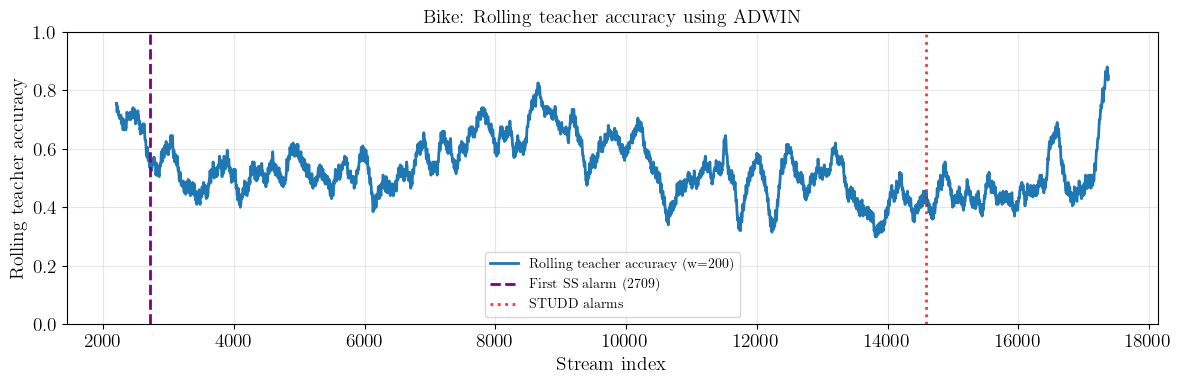

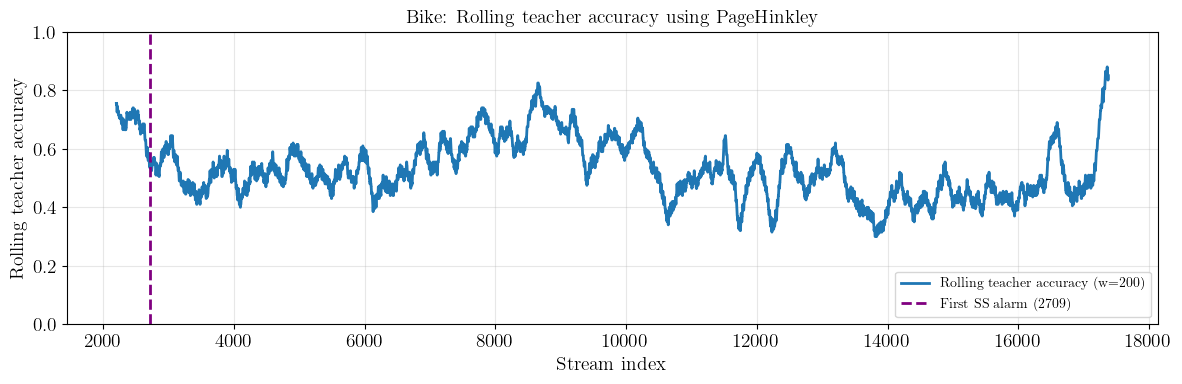

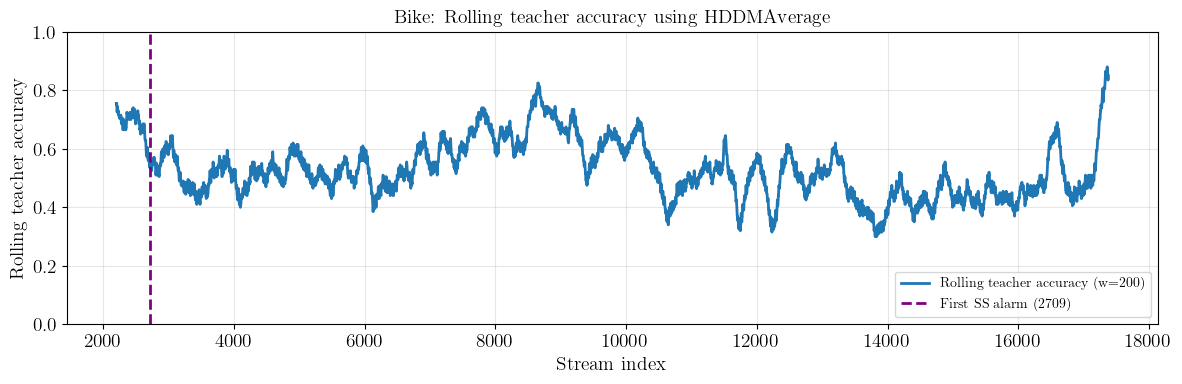

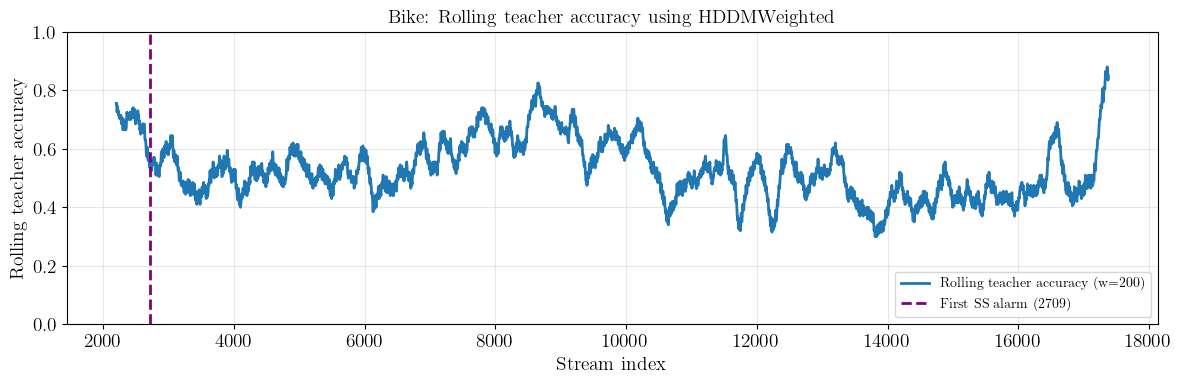

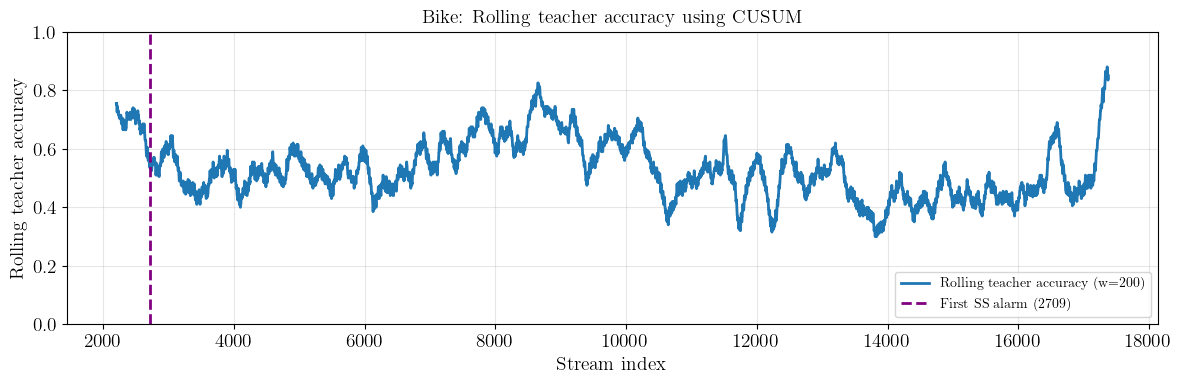

In [31]:
for detector_name, run in comparison_runs.items():

    results = run["results"]
    alarms = run["studd_drift_points"]

    rolling_accuracy, _ = rolling_mean(
        results["teacher_correct"].to_numpy(dtype=float),
        ROLLING_WINDOW,
    )

    rolling_t = results["t"].to_numpy()[
        ROLLING_WINDOW - 1:
    ]

    plt.figure(figsize=(12, 4))

    plt.plot(
        rolling_t,
        rolling_accuracy,
        linewidth=2,
        label=f"Rolling teacher accuracy (w={ROLLING_WINDOW})",
    )

    plt.axvline(
        reference_drift,
        color="purple",
        linestyle="--",
        linewidth=2,
        label=f"First SS alarm ({reference_drift})",
    )

    for i, alarm in enumerate(alarms):
        plt.axvline(
            alarm,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(f"Bike: Rolling teacher accuracy using {detector_name}")
    plt.xlabel("Stream index")
    plt.ylabel("Rolling teacher accuracy")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Rolling teacher-student disagreement

The following plots show the rolling teacher-student disagreement for each detector.

This is the signal monitored by STUDD.

The first SS alarm is shown as a purple dashed line and is used as the reference drift point.

STUDD alarms are shown as red dotted lines.

The rolling disagreement curve is computed with a window of 200 observations.

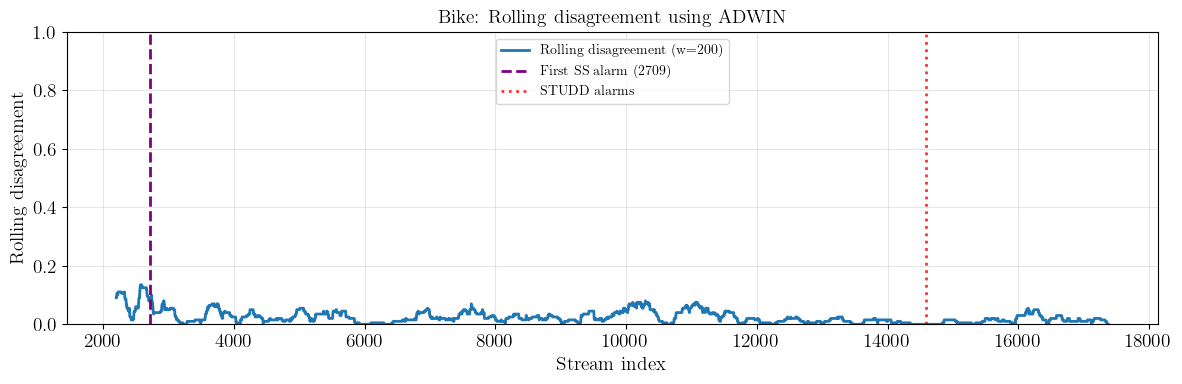

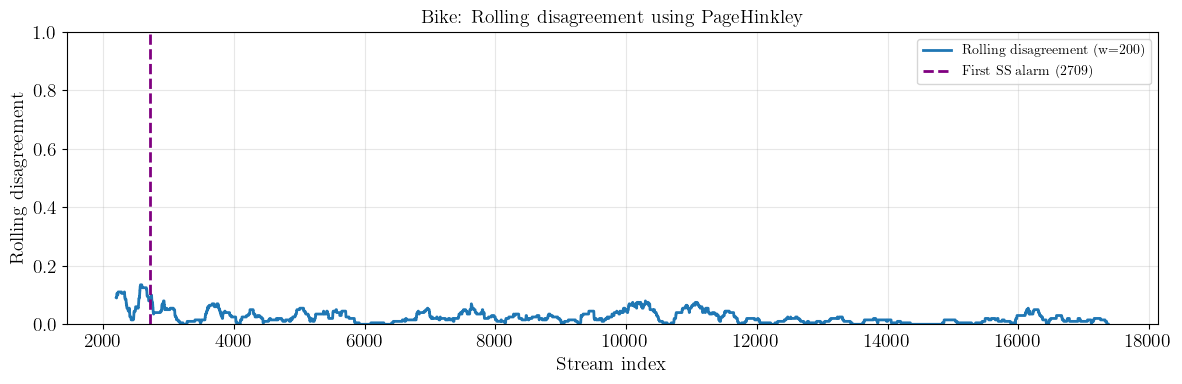

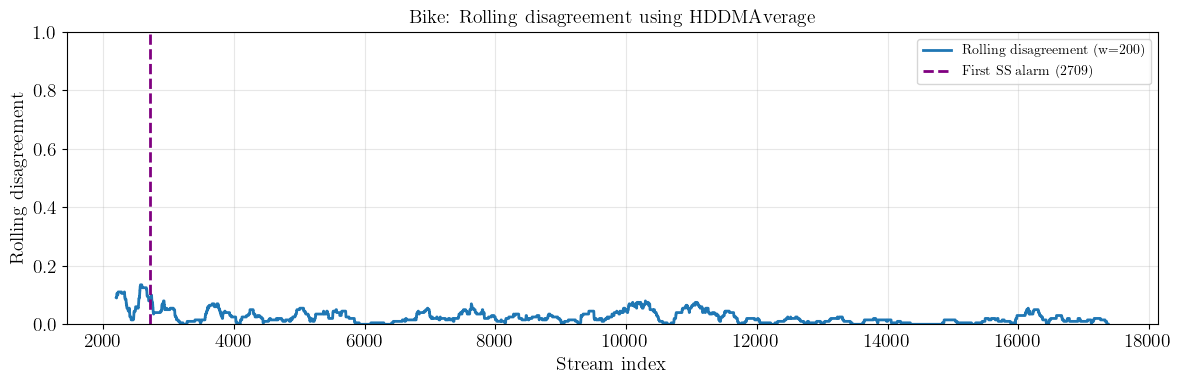

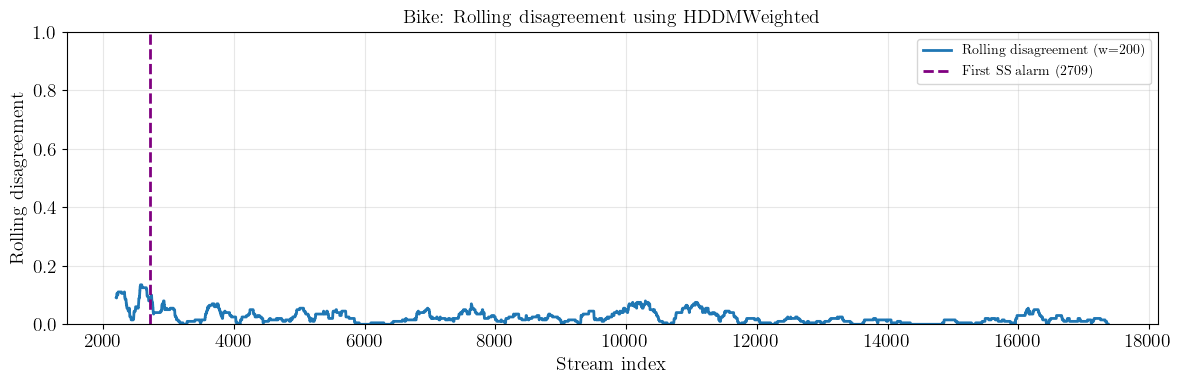

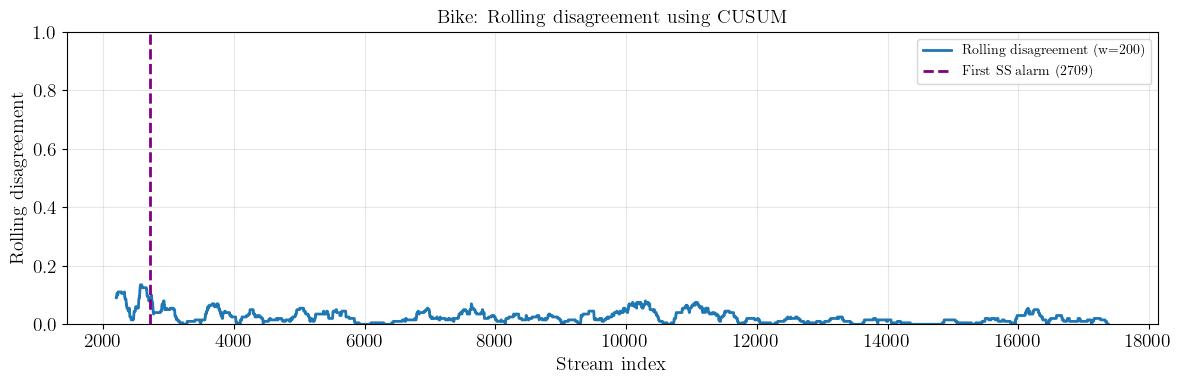

In [32]:
for detector_name, run in comparison_runs.items():

    results = run["results"]
    alarms = run["studd_drift_points"]

    rolling_disagreement = (
        results["disagreement"]
        .rolling(
            window=ROLLING_WINDOW,
            min_periods=1,
        )
        .mean()
    )

    rolling_t = results["t"]

    plot_mask = results["t"] >= W + ROLLING_WINDOW

    plt.figure(figsize=(12, 4))

    plt.plot(
        rolling_t[plot_mask],
        rolling_disagreement[plot_mask],
        linewidth=2,
        label=f"Rolling disagreement (w={ROLLING_WINDOW})",
    )

    plt.axvline(
        reference_drift,
        color="purple",
        linestyle="--",
        linewidth=2,
        label=f"First SS alarm ({reference_drift})",
    )

    for i, alarm in enumerate(alarms):
        plt.axvline(
            alarm,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(f"Bike: Rolling disagreement using {detector_name}")
    plt.xlabel("Stream index")
    plt.ylabel("Rolling disagreement")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Detector comparison summary

This notebook compares the effect of changing the detector inside STUDD on the Bike dataset.

The first SS alarm is used as a reference drift indication.

The key quantities are:

- number of alarms : total number of alarms produced by each detector
- closest alarm delay from ss : distance between the closest STUDD alarm and the first SS alarm
- reference accuracy delta : change in teacher accuracy around the first SS alarm
- reference disagreement delta : change in teacher-student disagreement around the first SS alarm
- closest alarm accuracy delta : change in teacher accuracy around the closest STUDD alarm
- closest alarm disagreement delta : change in teacher-student disagreement around the closest STUDD alarm

For Bike, the STUDD paper describes a difficult case for the method: the teacher may perform poorly while the student still mimics the teacher well. In that case, teacher-student disagreement may remain stable even when true predictive performance is poor.

After the previous analysis, it is obvious that:

The SS detector identifies several changes in teacher error, but most STUDD detector variants do not trigger alarms. This suggests that the teacher-student disagreement signal remains relatively stable, even though the true teacher performance changes.

This behaviour is consistent with the Bike example discussed in the STUDD paper, where the student can keep mimicking a poorly performing teacher. In such cases, STUDD may fail to detect drift because the mimicking loss does not increase enough.